# Disaster Tweet Classification - DistilBERT vs. TF-IDF Baseline
**43024 Introduction to Computational Intelligence - Group Project**

Authors: Marc Mory (25476247), Sunny Grover (25573039)

This notebook identifies whether a tweet refers to a **real disaster**. It is a binary
text-classification task. We fine-tune **DistilBERT** (a small, fast transformer) and
compare it against a traditional **TF-IDF + Logistic Regression** baseline.

**Dataset:** Kaggle *Natural Language Processing with Disaster Tweets*
(https://www.kaggle.com/c/nlp-getting-started) - 7,613 hand-labelled tweets.

**How to run:** Set the runtime to **GPU**
(`Runtime > Change runtime type > T4 GPU`).
A full run takes only a few minutes on the free tier.

## 1. Setup

In [15]:
!pip -q install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 66.2 MB/s eta 0:00:00


In [16]:
import re, numpy as np, pandas as pd, torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

Running on: cuda


## 2. Load the data

The training file `train.csv` is the Kaggle Disaster Tweets dataset. For a one-click run
we download the identical CSV from a public mirror. (Alternatively, upload `train.csv`
from the project repository, or use the Kaggle API.)

In [17]:
!wget -q -O train.csv https://raw.githubusercontent.com/Briiick/NLP-disaster-tweets/main/data/raw/train.csv
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df[["text", "target"]].head()

Shape: (7613, 5)


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [18]:
print("Class balance (0 = non-disaster, 1 = disaster):")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3).to_dict())
print("Average tweet length (characters):", round(df["text"].str.len().mean(), 1))

Class balance (0 = non-disaster, 1 = disaster):
target
0    4342
1    3271
Name: count, dtype: int64
{0: 0.57, 1: 0.43}
Average tweet length (characters): 101.0


## 3. Text preprocessing

Tweets are noisy: URLs, @mentions, hashtags, HTML entities and stray symbols add little
signal. The same cleaning function is applied to **both** models so the comparison is fair.

In [19]:
URL     = re.compile(r"https?://\S+|www\.\S+")
MENTION = re.compile(r"@\w+")
HASH    = re.compile(r"#")
NONWORD = re.compile(r"[^a-zA-Z0-9\s']")
SPACES  = re.compile(r"\s+")

def clean_text(t):
    t = str(t).lower()
    t = URL.sub(" ", t)
    t = MENTION.sub(" ", t)
    t = HASH.sub(" ", t)
    t = t.replace("&amp;", " and ").replace("&lt;", " ").replace("&gt;", " ")
    t = NONWORD.sub(" ", t)
    t = SPACES.sub(" ", t).strip()
    return t

df["clean"] = df["text"].apply(clean_text)
for i in range(3):
    print("RAW:", df["text"].iloc[i])
    print("CLN:", df["clean"].iloc[i], "\n")

RAW: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
CLN: our deeds are the reason of this earthquake may allah forgive us all 

RAW: Forest fire near La Ronge Sask. Canada
CLN: forest fire near la ronge sask canada 

RAW: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
CLN: all residents asked to 'shelter in place' are being notified by officers no other evacuation or shelter in place orders are expected 



## 4. Train / test split

An 80/20 **stratified** split keeps the same class ratio in both sets. The split is fixed
with `random_state=42` so both models - and every re-run - see exactly the same data.

In [20]:
train_texts, test_texts, y_train, y_test = train_test_split(
    df["clean"].tolist(), df["target"].tolist(),
    test_size=0.20, stratify=df["target"], random_state=SEED)
print("Train tweets:", len(train_texts))
print("Test tweets :", len(test_texts))

Train tweets: 6090
Test tweets : 1523


In [21]:
def report(name, y_true, y_pred):
    scores = dict(
        acc=accuracy_score(y_true, y_pred),
        prec=precision_score(y_true, y_pred),
        rec=recall_score(y_true, y_pred),
        f1=f1_score(y_true, y_pred),
        cm=confusion_matrix(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"Accuracy : {scores['acc']:.4f}")
    print(f"Precision: {scores['prec']:.4f}")
    print(f"Recall   : {scores['rec']:.4f}")
    print(f"F1 (pos) : {scores['f1']:.4f}")
    return scores

## 5. Baseline - TF-IDF + Logistic Regression

TF-IDF turns each tweet into a sparse vector of weighted word/bigram counts; Logistic
Regression then classifies those vectors. This is a strong, fast, classical text-classification
baseline that relies only on word-frequency patterns.

In [22]:
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9,
                      sublinear_tf=True, stop_words="english", max_features=20000)
X_tr = vec.fit_transform(train_texts)
X_te = vec.transform(test_texts)
print("TF-IDF feature matrix:", X_tr.shape)

baseline = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
baseline.fit(X_tr, y_train)
base_pred = baseline.predict(X_te)
base_scores = report("Baseline: TF-IDF + Logistic Regression", y_test, base_pred)

TF-IDF feature matrix: (6090, 9093)
--- Baseline: TF-IDF + Logistic Regression ---
Accuracy : 0.8221
Precision: 0.8501
Recall   : 0.7110
F1 (pos) : 0.7744


## 6. DistilBERT - fine-tuned transformer

DistilBERT is a distilled version of BERT: ~40% smaller and ~60% faster while keeping most
of BERT's language understanding (Sanh et al., 2019). We add a 2-class classification head
and fine-tune the whole model on the disaster-tweet task.

### 6.1 Tokenisation

In [23]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 64
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TweetDataset(Dataset):
    """Tokenises tweets once and serves tensors to the DataLoader."""
    def __init__(self, texts, labels):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return {"input_ids":      self.enc["input_ids"][i],
                "attention_mask": self.enc["attention_mask"][i],
                "labels":         self.labels[i]}

train_ds = TweetDataset(train_texts, y_train)
test_ds  = TweetDataset(test_texts,  y_test)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=32)
print("Tokenisation done. Example token IDs:")
print(train_ds[0]["input_ids"][:20])

Tokenisation done. Example token IDs:
tensor([  101, 21871,  6508,  2103,  2611,  2406, 15876,  8950, 15577,  1999,
        20629,  3137,  4586, 19718, 20118,  5244, 21307, 14659, 14301,  2063])


### 6.2 Fine-tuning

The pretrained encoder plus the new classification head are trained with the AdamW
optimiser and cross-entropy loss (returned automatically by the model when `labels`
are supplied). Transformers overfit quickly on small datasets, so only a few epochs
are needed.

In [24]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=2e-5)
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for batch in train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        running += out.loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}  -  average training loss = {running/len(train_dl):.4f}")

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3  -  average training loss = 0.4386
Epoch 2/3  -  average training loss = 0.3279
Epoch 3/3  -  average training loss = 0.2313


### 6.3 Evaluation on the held-out test set

In [25]:
model.eval()
bert_pred = []
with torch.no_grad():
    for batch in test_dl:
        batch.pop("labels")
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        bert_pred.extend(torch.argmax(logits, dim=1).cpu().tolist())

bert_scores = report("DistilBERT (fine-tuned)", y_test, bert_pred)
print()
print(classification_report(y_test, bert_pred,
                            target_names=["non-disaster", "disaster"]))

--- DistilBERT (fine-tuned) ---
Accuracy : 0.8293
Precision: 0.8107
Recall   : 0.7859
F1 (pos) : 0.7981

              precision    recall  f1-score   support

non-disaster       0.84      0.86      0.85       869
    disaster       0.81      0.79      0.80       654

    accuracy                           0.83      1523
   macro avg       0.83      0.82      0.83      1523
weighted avg       0.83      0.83      0.83      1523



## 7. Results and comparison

The table and confusion matrices below summarise both models on the **same** test set.
Copy these numbers into the project report (Table 1 and the confusion-matrix figure).

In [26]:
comparison = pd.DataFrame({
    "Model":     ["TF-IDF + Logistic Regression", "DistilBERT (fine-tuned)"],
    "Accuracy":  [base_scores["acc"],  bert_scores["acc"]],
    "Precision": [base_scores["prec"], bert_scores["prec"]],
    "Recall":    [base_scores["rec"],  bert_scores["rec"]],
    "F1":        [base_scores["f1"],   bert_scores["f1"]],
}).round(4)
print(comparison.to_string(index=False))

                       Model  Accuracy  Precision  Recall     F1
TF-IDF + Logistic Regression    0.8221     0.8501  0.7110 0.7744
     DistilBERT (fine-tuned)    0.8293     0.8107  0.7859 0.7981


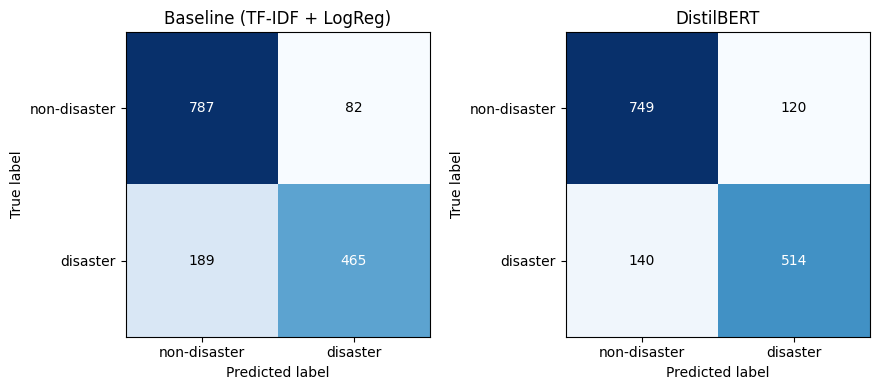

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, sc, title in zip(axes, [base_scores, bert_scores],
                         ["Baseline (TF-IDF + LogReg)", "DistilBERT"]):
    cm = sc["cm"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["non-disaster", "disaster"])
    ax.set_yticklabels(["non-disaster", "disaster"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=200)
plt.show()

## 8. Qualitative error analysis

A few hand-written examples show how a context-aware model handles figurative language
(`fire`, `attack`, `meltdown`) that a word-frequency baseline tends to misread.

In [28]:
samples = [
    "Forest fire near La Ronge Sask. Canada",
    "this new album is straight fire",
    "13000 people receive wildfires evacuation orders in California",
    "my anxiety attack ruined the whole evening",
    "BREAKING building collapse downtown multiple people trapped",
    "the crowd went into total meltdown when the band came on stage",
]
enc = tokenizer([clean_text(s) for s in samples], truncation=True,
                padding=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
model.eval()
with torch.no_grad():
    pred = torch.argmax(model(**enc).logits, dim=1).cpu().tolist()
for s, p in zip(samples, pred):
    print(f"[{'DISASTER' if p == 1 else 'non-disaster'}]  {s}")

[DISASTER]  Forest fire near La Ronge Sask. Canada
[non-disaster]  this new album is straight fire
[DISASTER]  13000 people receive wildfires evacuation orders in California
[non-disaster]  my anxiety attack ruined the whole evening
[DISASTER]  BREAKING building collapse downtown multiple people trapped
[non-disaster]  the crowd went into total meltdown when the band came on stage


## 9. Summary

The notebook trains and compares two models for disaster-tweet classification under free
Colab constraints. The baseline relies on word frequencies alone, while fine-tuned
DistilBERT uses self-attention to interpret each word in context. See the project report
for the full discussion of results, limitations and future work.